# SMS SPAM DETECTION - by classification

In [1]:
import numpy as np
import pandas as pd 

In [2]:
df = pd.read_csv('spam.csv',encoding ='latin-1') #we add the parameter of encoding to avoid the default utf-8 encoding error
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.sample(5)
#gives randomly 5 entries from the dataset - a sample size of 5 

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1413,spam,Dear U've been invited to XCHAT. This is our f...,NaN,NaN,NaN
2567,ham,I dont want to hear anything,NaN,NaN,NaN
2621,ham,Lol! Nah wasn't too bad thanks. Its good to b ...,NaN,NaN,NaN
3326,ham,what number do u live at? Is it 11?,NaN,NaN,NaN
2031,ham,"I noe la... U wana pei bf oso rite... K lor, o...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

 # Steps to perform in this project 
 1. Data cleaning 
 2. EDA 
 3. Text preprocessing
 4. model building 
 5. evaluation 
 6. improvements
 7. website 
 8. deploy

## 1. Data Cleaning

### Dropping columns with sparse values

In [5]:
#checking which columns can be dropped - columns that are mostly sparse 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [6]:
#last 3 columns have barely any non null values hence we can completely drop them 
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [7]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
#make the column names more clear and descriptive by renaming the columns 
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
2272,ham,"Haha awesome, I've been to 4u a couple times. ..."
4672,ham,I forgot 2 ask Ì_ all smth.. There's a card on...
1507,ham,"Wen ur lovable bcums angry wid u, dnt take it ..."
4400,ham,Many times we lose our best ones bcoz we are
4231,ham,I'm at home. Please call


### Label Encoding the Target Column

#### Why do we need to convert `ham` and `spam` into numbers?

Our `target` column contains categorical labels:

```text
ham
spam
```

These labels represent the class of each SMS:

- **ham** → Normal / non-spam message
- **spam** → Spam message

Most Machine Learning algorithms expect the **target/output to be represented numerically** rather than as words.

Therefore, we convert:

```text
ham  → 0
spam → 1
```

After conversion, our problem becomes a **Binary Classification Problem** because there are only two possible classes:

```text
0 → Ham
1 → Spam
```

---

#### Using `LabelEncoder`

We use `LabelEncoder` from Scikit-learn:

```python
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
```

`LabelEncoder` is used to convert **categorical labels into numerical labels**.

To transform the target column:

```python
df['target'] = encoder.fit_transform(df['target'])
```

---

#### What does `fit_transform()` do?

`fit_transform()` performs two operations:

##### 1. `fit()`

Learns/finds the unique categories present in the column.

For example:

```text
ham
spam
```

##### 2. `transform()`

Assigns numerical values to those categories.

```text
ham  → 0
spam → 1
```

Therefore:

```python
encoder.fit_transform(df['target'])
```

converts something like:

```text
ham
ham
spam
ham
spam
```

into:

```text
0
0
1
0
1
```

So:

```text
fit_transform()
      ↓
fit + transform
      ↓
learn categories + convert them into numbers
```

---

#### Important: Why don't we use `LabelEncoder` on the SMS text?

`LabelEncoder` is being used only on the **target column**:

```text
ham / spam
    ↓
LabelEncoder
    ↓
0 / 1
```

The actual SMS messages contain textual information such as:

```text
"Congratulations! You have won a prize."
```

We cannot simply assign one number to each entire message because the Machine Learning model needs to understand the **words/features inside the message**.

Therefore, the `text` column will later require **text preprocessing and vectorization**.

```text
SMS Text
    ↓
Text Preprocessing
    ↓
Vectorization (e.g. Bag of Words / TF-IDF)
    ↓
Numerical Feature Vector
    ↓
Machine Learning Model
```

---

#### Overall Idea

Before:

| text | target |
|---|---|
| Hey, how are you? | ham |
| Congratulations! You won a prize | spam |

After Label Encoding:

| text | target |
|---|---:|
| Hey, how are you? | 0 |
| Congratulations! You won a prize | 1 |

The **target** is now numerical and can be used for training a classification model.

---

#### Quick Revision

- `LabelEncoder` converts **categorical labels → numerical labels**.
- It is available in `sklearn.preprocessing`.
- Here:
  - `ham → 0`
  - `spam → 1`
- `fit()` → learns the unique categories.
- `transform()` → converts categories into numbers.
- `fit_transform()` → performs both operations together.
- It is used here for the **target/output column**.
- The SMS `text` column will instead require **text vectorization** such as Bag of Words or TF-IDF.

```python
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['target'] = encoder.fit_transform(df['target'])
```

In [9]:
#Label encoding the target column 
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder() #making a labelEncoder object 


In [10]:
df['target']=encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Checking for missing values 

In [11]:
df.isnull().sum()

target    0
text      0
dtype: int64

### Checking for duplicate values 

In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
#removing those duplicates
df = df.drop_duplicates(keep='first')
df.shape

(5169, 2)

## 2. EDA

In [14]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [16]:
# hence this shows we have a much higher percentage of NOT spam sms as compared to spam messages 
#this can be effectively visualised using a pie chart 


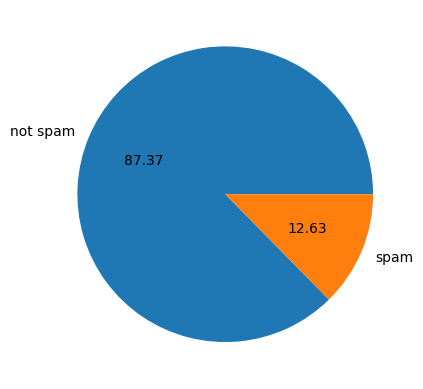

In [17]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['not spam', 'spam'],autopct="%0.2f")
plt.show() #used to see only the chart and not the pie object

##### Visualising Spam vs Non-Spam Distribution using a Pie Chart

```python
import matplotlib.pyplot as plt

plt.pie(
    df['target'].value_counts(),
    labels=['not spam', 'spam'],
    autopct="%0.2f"
)

plt.show()
```

###### Explanation

- `import matplotlib.pyplot as plt`  
  Imports Matplotlib's plotting module and gives it the alias `plt`.

- `df['target'].value_counts()`  
  Counts how many messages belong to each target class.

  Since the target was label encoded:

  ```text
  0 → Not Spam (Ham)
  1 → Spam
  ```

- `plt.pie(...)`  
  Creates a **pie chart** showing the proportion of spam and non-spam messages.

- `labels=['not spam', 'spam']`  
  Gives names to the two sections of the pie chart.

- `autopct="%0.2f"`  
  Displays the percentage of each category on the chart, rounded to **2 decimal places**.

  Example:

  ```text
  86.59
  13.41
  ```

- `plt.show()`  
  Displays only the completed chart instead of also showing the Matplotlib pie-chart object/output.

###### Purpose

This helps us understand the **class distribution** of the dataset.

```text
Target column
     ↓
value_counts()
     ↓
Number of spam and non-spam messages
     ↓
plt.pie()
     ↓
Visual representation of class distribution
```

It also helps identify whether the dataset is **balanced or imbalanced** between spam and non-spam classes - **here the data is imbalanced**

### Analysis of the number of characters, number of words and number of sentences in the SMS 

In [18]:
import nltk

In [19]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

#### counting the number of characters

In [20]:
df['text']

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: text, Length: 5169, dtype: str

In [21]:
df['num_characters']=df['text'].apply(len)

#this gives a new column storing the number of characters used in each sms

In [22]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


### counting the number of words in the sms 

In [23]:
import nltk

nltk.download('punkt_tab')
#nltk word tokeniser uses the punkt_tab

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [24]:
#num of words in each sms
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df.head()


,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


#### Using `split()` vs `nltk.word_tokenize` for Word Count

If we only want to count the number of words in each SMS, we can use Python's built-in `split()` function.

```python
df['num_words'] = df['text'].apply(lambda x: len(x.split()))
```

##### How it works

`x.split()` splits a string based on whitespace.

Example:

```python
text = "Hello how are you?"
text.split()
```

Output:

```text
['Hello', 'how', 'are', 'you?']
```

Then:

```python
len(text.split())
```

returns:

```text
4
```

So for every SMS:

```text
SMS text
   ↓
split()
   ↓
list of words
   ↓
len()
   ↓
number of words
```

---

##### `split()` vs `nltk.word_tokenize()`

`split()` performs simple whitespace-based splitting.

Example:

```python
"Hello, how are you?".split()
```

Output:

```text
['Hello,', 'how', 'are', 'you?']
```

Punctuation remains attached to the words.

`nltk.word_tokenize()` performs more proper NLP tokenization:

```python
nltk.word_tokenize("Hello, how are you?")
```

Output may be:

```text
['Hello', ',', 'how', 'are', 'you', '?']
```

So punctuation is treated as separate tokens.

---

##### When to use which?

- `split()` → simple, fast and sufficient for a rough word count during EDA.
- `nltk.word_tokenize()` → better when proper NLP tokenization is required.


```

### counting the number of sentences

In [25]:
df['num_sentence']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [26]:
# roughly analysing the features using describe 
df[['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.460437,1.965564
std,58.236293,13.334441,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
# analysing based on spam/not spam : each feature using describe 

#for not spam messages:
df[df['target']==0][['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.128432,1.820195
std,56.358207,13.504730,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
#for spam messages:
df[df['target']==1][['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.672282,2.970904
std,30.137753,7.010932,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


NOTE : that spam messages generally have a higher number of words, sentences and character count 

In [29]:
#TO SEE THE DISTINCTION BETWEEN THE NUMBER OF CHAR, WORDS AND SENTENCES BETWEEN SPAMAND NOT SPAM - WE CAN USE A HISTOGRAM

import seaborn as sns


<Axes: xlabel='num_characters', ylabel='Count'>

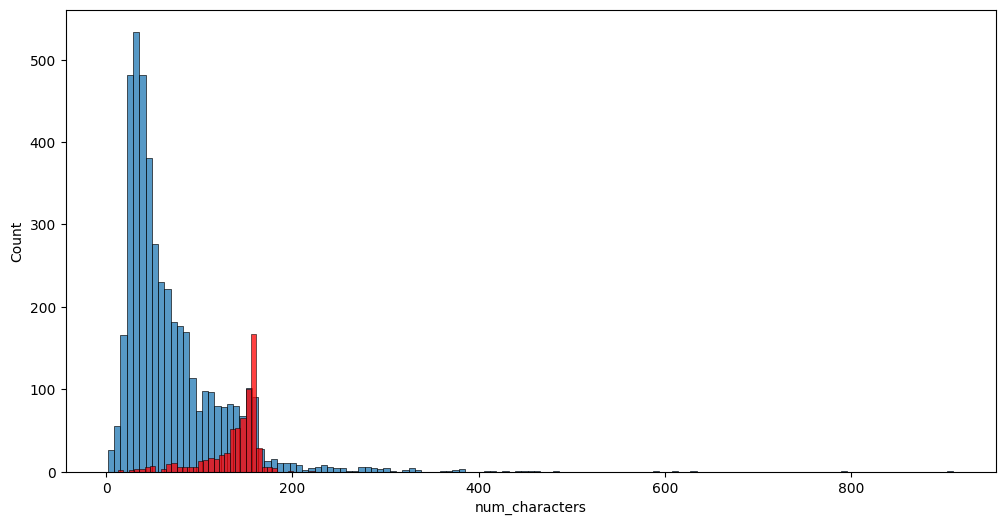

In [30]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

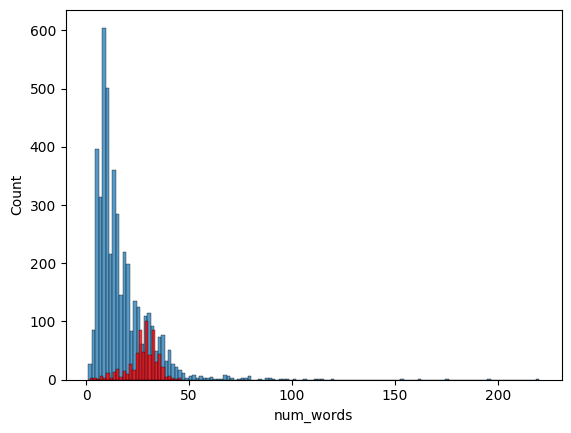

In [31]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

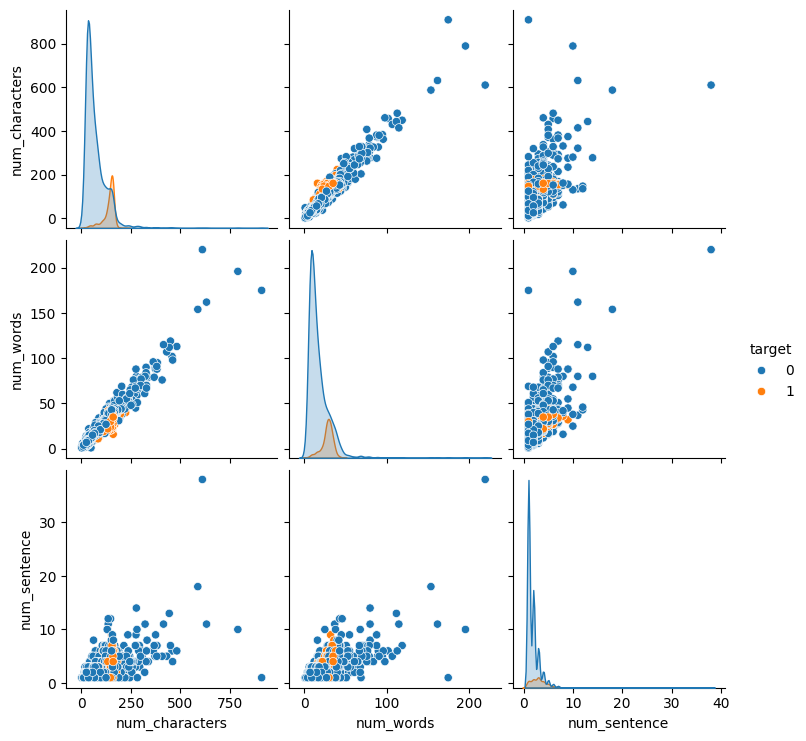

In [32]:
#DEFINING THE RELATIONSHIP BETWEEN FEATURES LIKE - WORDS AND SENTENCES USING A PAIRPLOT 
sns.pairplot(df,hue='target')

**we observe from the above that there are several outliers in the data that can impact our classifier model**

In [33]:
#CALCULATING THE CORRELATION COEFFICIENT BETWEEN FEATURES AND PLOTTING A HEATMAP

#df.corr() - wasnt working since it was trying to calculate correlation using all the columns includinf the text column 
df.corr(numeric_only=True)


,target,num_characters,num_words,num_sentence
target,1.000000,0.384717,0.262720,0.263939
num_characters,0.384717,1.000000,0.965686,0.624139
num_words,0.262720,0.965686,1.000000,0.679767
num_sentence,0.263939,0.624139,0.679767,1.000000


<Axes: >

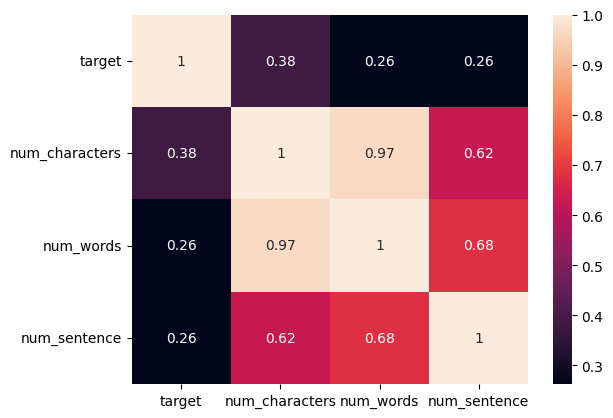

In [34]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

#### Correlation Heatmap — Feature Selection

A **correlation heatmap** shows how strongly numerical variables are related to each other.

The correlation coefficient ranges from:

```text
+1  → Strong positive correlation
 0  → Little or no linear correlation
-1  → Strong negative correlation
```

---

##### Correlation with the Target

Our target is:

```text
0 → Ham / Not Spam
1 → Spam
```

From the heatmap:

```text
target ↔ num_characters = 0.38
target ↔ num_words      = 0.26
target ↔ num_sentence   = 0.26
```

A positive correlation means that as the feature value increases, the message is somewhat more likely to belong to the spam class.

Among these features:

```text
num_characters → 0.38
```

has the **strongest correlation with the target**.

This suggests that spam messages tend to have more characters compared with ham messages.

---

#### Correlation Between the Input Features

The input features are also strongly correlated with one another:

```text
num_characters ↔ num_words    = 0.97
num_characters ↔ num_sentence = 0.62
num_words      ↔ num_sentence = 0.68
```

The strongest relationship is:

```text
num_characters ↔ num_words = 0.97
```

This is expected because longer messages usually contain:

```text
more characters
      ↓
more words
      ↓
often more sentences
```

So these features are largely describing the same property:

**message length**

---

#### Why Not Use All Three Features?

If we use:

```text
num_characters
num_words
num_sentences
```

together, we may be giving the model a lot of **redundant information**.

For example:

```text
num_characters ─┐
                │
num_words ──────┼──→ mostly represent message length
                │
num_sentences ──┘
```

Since `num_characters` and `num_words` have a correlation of `0.97`, they carry very similar information.

Using strongly correlated features together can also cause **multicollinearity**, especially in linear models.

---

#### Why Keep `num_characters`?

Among the three length-related features:

```text
num_characters → correlation with target = 0.38
num_words      → correlation with target = 0.26
num_sentence   → correlation with target = 0.26
```

`num_characters` has the highest correlation with the target.

Therefore, if we want to keep only one representative feature, `num_characters` is the better choice.

```text
Highly correlated input features
           ↓
Avoid redundant information
           ↓
Choose the feature with stronger relation to target
           ↓
num_characters
```

---

#### Important Note

Highly correlated features are **not always forbidden**.

However, if multiple features carry almost the same information, keeping all of them may be unnecessary.

For a simple model, selecting one representative feature can:

- Reduce redundancy
- Simplify the model
- Reduce multicollinearity
- Make feature interpretation easier

---

#### Duplicate Column Observation

The heatmap contains both:

```text
num_sentece
num_sentence
```

and their correlation is:

```text
1.00
```

This most likely means the sentence-count feature was accidentally created twice with different spellings.

A correlation of `1.00` means the two columns contain identical values.

We can check using:

```python
df.columns
```

and remove the duplicate column if required.

---

#### Quick Revision

```text
Correlation with target:

num_characters → 0.38  ← strongest
num_words      → 0.26
num_sentence   → 0.26


Correlation between features:

characters ↔ words      → 0.97  ← very strong
characters ↔ sentences  → 0.62
words ↔ sentences       → 0.68
```

##### Final Reasoning

```text
All three features describe message length
                ↓
They are strongly correlated with each other
                ↓
Using all may add redundant information
                ↓
num_characters has the strongest correlation with target
                ↓
Keep num_characters as the representative feature
```

## 3. Data preprocessing 

- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [35]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [36]:
# to view stopwords in english recognised by nltk and punctuations 
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [37]:
# to view punctuations
import string
string.punctuation


stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

In [38]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [39]:
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def transform_text(text):
    # lowercase
    text = text.lower()

    # tokenize
    text = nltk.word_tokenize(text)

    # keep only alphanumeric tokens
    y = []
    for word in text:
        if word.isalnum():
            y.append(word)

    # remove stopwords and punctuation
    text = y
    y = []

    for word in text:
        if word not in stop_words and word not in punctuation:
            y.append(word)

    # stemming
    text = y
    y = []

    for word in text:
        y.append(ps.stem(word))

    return " ".join(y)

In [40]:
transform_text('HI HOW ARE U @#!!, i loved youtube lectures on ML, what about you?')

'hi u love youtub lectur ml'

In [41]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,num_characters,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [42]:
#df.drop('transformed_text',axis=1,inplace=True)

In [43]:
df.head()

,target,text,num_characters,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


### Creating world-cloud - showcases the most important words in the text


In [44]:
%pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
from wordcloud import WordCloud
wc = WordCloud(width = 500,height=500,min_font_size=10,background_color='white')

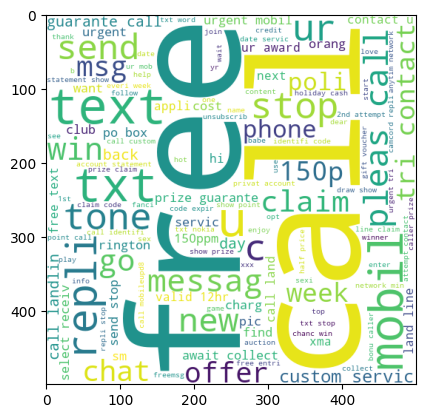

In [46]:
#for spam messages
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

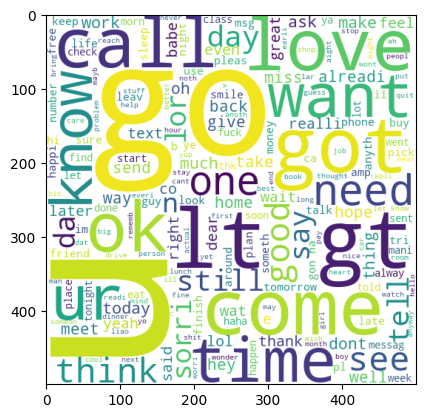

In [47]:
#for non-spam messages
n_spam_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(n_spam_wc)

**EXTRACTING TOP 30 WORDS IN SPAM AND NON-SPAM SMS**

In [48]:
df[df['target']==1]['transformed_text']

2       free entri 2 wkli comp win fa cup final tkt 21...
5       freemsg hey darl 3 week word back like fun sti...
8       winner valu network custom select receivea pri...
9       mobil 11 month u r entitl updat latest colour ...
11      six chanc win cash 100 pound txt csh11 send co...
                              ...                        
5537    want explicit sex 30 sec ring 02073162414 cost...
5540    ask 3mobil 0870 chatlin inclu free min india c...
5547    contract mobil 11 mnth latest motorola nokia e...
5566    remind o2 get pound free call credit detail gr...
5567    2nd time tri 2 contact u pound prize 2 claim e...
Name: transformed_text, Length: 653, dtype: str

In [49]:
# creating a list of strings out of the transformed text column
df[df['target']==1]['transformed_text'].tolist()

['free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18',
 'freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv',
 'winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour',
 'mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030',
 'six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info',
 'urgent 1 week free membership prize jackpot txt word claim 81010 c lccltd pobox 4403ldnw1a7rw18',
 'xxxmobilemovieclub use credit click wap link next txt messag click http',
 'england v macedonia dont miss news txt ur nation team 87077 eg england 87077 tri wale scotland poboxox36504w45wq',
 'thank subscript rington uk mobil charg pleas confirm repli ye repli charg',
 '07732584351 rodger burn msg tri call repli sm free nokia mobil free camcord pleas call 08000930705 deliveri tomorrow',
 '

In [50]:
#creating custom function to extract all the words in spam messages 

spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

n_spam_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        n_spam_corpus.append(word)
        

In [51]:
len(spam_corpus)

9942

In [52]:
len(n_spam_corpus)

35423

this gives the total words in the spam and not spam corpus

In [53]:
%pip install collection

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
from collections import Counter
Counter(spam_corpus)

Counter({'call': 320,
         'free': 191,
         '2': 155,
         'txt': 141,
         'text': 122,
         'u': 119,
         'ur': 119,
         'mobil': 114,
         'stop': 104,
         'repli': 103,
         'claim': 98,
         '4': 97,
         'prize': 82,
         'get': 74,
         'new': 64,
         'servic': 64,
         'tone': 63,
         'send': 60,
         'urgent': 57,
         'nokia': 57,
         'contact': 56,
         'award': 55,
         'phone': 52,
         'cash': 51,
         'pleas': 51,
         'week': 49,
         'win': 48,
         'c': 45,
         'collect': 45,
         'min': 45,
         'custom': 42,
         'messag': 42,
         'guarante': 42,
         'per': 41,
         'chat': 38,
         'tri': 37,
         'msg': 35,
         'draw': 35,
         'number': 35,
         'cs': 35,
         'show': 33,
         'today': 33,
         'offer': 33,
         'line': 33,
         'go': 32,
         'receiv': 31,
         'want': 3

Counter object when passed with spam_corpus returns a dictionary of spam words along with the number of times they occur in the corpus


In [55]:
#to extract most common 30 words 
Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

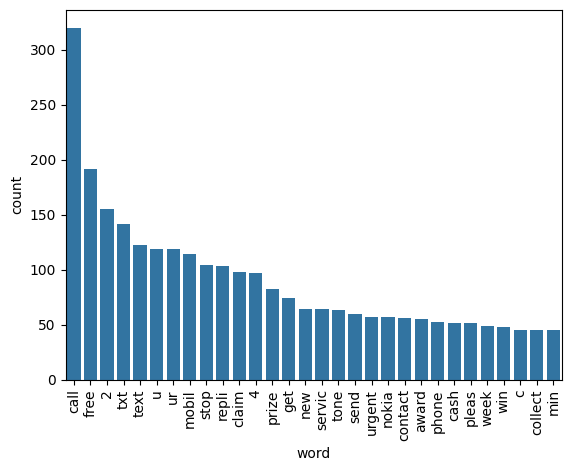

In [56]:
spam_df = pd.DataFrame(
    Counter(spam_corpus).most_common(30),
    columns=['word', 'count']
)

sns.barplot(x='word', y='count', data=spam_df)

plt.xticks(rotation='vertical') #this is used to place the words on the horizontal axis formatted such that they are in alignment with the bars  for readability
plt.show()

In [57]:
#not spam 

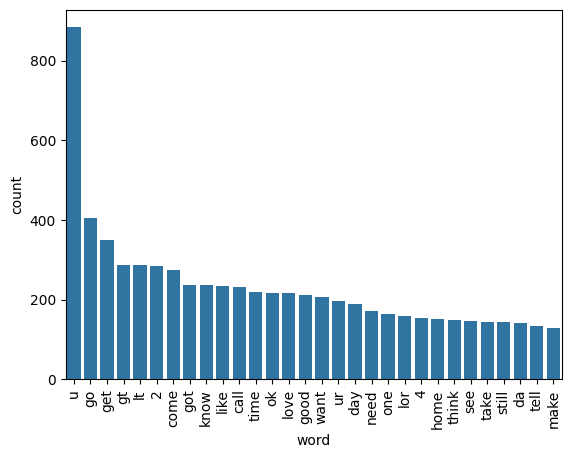

In [58]:
n_spam_df = pd.DataFrame(
    Counter(n_spam_corpus).most_common(30),
    columns=['word', 'count']
)

# Plot
sns.barplot(x='word', y='count', data=n_spam_df)

plt.xticks(rotation='vertical')
plt.show()

## 4. Model Building

For starters, we use the Naive Bayes algorithm since its known the perform the best on textual data


for machine learning models to be formulated and trained we require numerical inputs and here we have textual imput as well (transformed_text)

### Vectorization


In [59]:
#vectorization technique used here is TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
#Keep at most the 3000 most useful vocabulary features instead of creating one feature for every unique word.

X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

### TF-IDF Vectorization

We have already cleaned our SMS messages and stored the processed text in:

```python
df['transformed_text']
```

However, Machine Learning models cannot directly understand text.  
Therefore, we need to convert the text into **numerical vectors**.

Here we use **TF-IDF (Term Frequency–Inverse Document Frequency)** as our vectorization technique.

---

#### Code

```python
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed_text']).toarray()

y = df['target'].values
```

---

#### 1. Import `TfidfVectorizer`

```python
from sklearn.feature_extraction.text import TfidfVectorizer
```

Imports the `TfidfVectorizer` class from Scikit-learn.

Its job is to:

```text
Text
 ↓
TF-IDF Vectorization
 ↓
Numerical Features
```

For example:

```text
"free prize win"
        ↓
[0.0, 0.64, 0.51, 0.0, 0.57, ...]
```

Each number represents the TF-IDF importance of a vocabulary word in that message.

---

#### 2. Create the TF-IDF Vectorizer

```python
tfidf = TfidfVectorizer(max_features=3000)
```

This creates a `TfidfVectorizer` object and stores it in:

```python
tfidf
```

##### `max_features=3000`

This limits the vocabulary to **at most 3000 features/words**.

Instead of creating a feature for every unique word in the complete dataset:

```text
All unique words
      ↓
possibly thousands of columns
```

we restrict it to:

```text
Maximum 3000 vocabulary features
```

This helps:

- Reduce dimensionality
- Reduce unnecessary features
- Use less memory
- Make model training faster

---

#### 3. Convert the SMS Text into TF-IDF Vectors

```python
X = tfidf.fit_transform(df['transformed_text']).toarray()
```

This is the main vectorization step.

##### `df['transformed_text']`

Contains our cleaned SMS messages.

Example:

```text
free entri wkli comp win fa cup final
ok lar joke wif u oni
nah think goe usf live around
```

---

##### `fit_transform()`

```python
tfidf.fit_transform(df['transformed_text'])
```

performs two operations:

```text
fit()
 +
transform()
```

##### `fit()`

Learns the vocabulary from all SMS messages and calculates the IDF values.

Conceptually:

```text
All transformed SMS messages
        ↓
Find vocabulary
        ↓
Learn importance of words across dataset
```

---

##### `transform()`

Converts each SMS into a numerical vector using the learned vocabulary and TF-IDF weights.

```text
SMS Message
    ↓
TF-IDF
    ↓
Numerical Vector
```

So:

```python
fit_transform()
```

means:

```text
Learn vocabulary + IDF values
              ↓
Convert all SMS messages into vectors
```

---

#### 4. What Does TF-IDF Measure?

TF-IDF stands for:

```text
TF  → Term Frequency
IDF → Inverse Document Frequency
```

##### Term Frequency (TF)

Measures how frequently a word occurs in a particular SMS.

```text
"free free prize"

free appears multiple times
→ higher TF
```

##### Inverse Document Frequency (IDF)

Reduces the importance of words that occur in many messages and gives more importance to relatively uncommon/informative words.

Therefore, TF-IDF gives a higher weight to words that are:

```text
important in a particular message
+
not extremely common across all messages
```

---

#### 5. `.toarray()`

```python
.toarray()
```

`fit_transform()` normally returns a **sparse matrix**.

A text dataset contains many zeros because one SMS contains only a small fraction of the entire vocabulary.

Example:

```text
          free   prize   meeting   hello   winner

SMS 1     0.71   0.55      0        0      0.43
SMS 2      0      0       0.62     0.74      0
```

Most values are `0`.

A sparse matrix stores this efficiently.

```python
.toarray()
```

converts the sparse matrix into a normal dense NumPy array.

Therefore:

```python
X
```

contains the numerical input features that will be given to our Machine Learning model.

> Note: `.toarray()` is convenient for learning and small datasets, but for large text datasets it is often better to keep the sparse matrix to save memory.

---

#### 6. Creating the Target Variable

```python
y = df['target'].values
```

`df['target']` contains our encoded output labels:

```text
0 → Ham / Not Spam
1 → Spam
```

`.values` extracts these values from the Pandas Series as a NumPy array.

Example:

```text
[0, 0, 1, 0, 1, 0, ...]
```

This is stored in:

```python
y
```

---

#### Final Meaning of `X` and `y`

```text
X → Input / Independent Features
y → Output / Target
```

##### `X`

Contains the TF-IDF numerical vectors of the SMS messages.

```text
transformed_text
       ↓
TF-IDF Vectorizer
       ↓
X
```

##### `y`

Contains the correct classification labels.

```text
target
 ↓
0 / 1
 ↓
y
```

Therefore:

```text
X                           y

TF-IDF vectors              Correct labels
of SMS messages             0 = Ham
                            1 = Spam
       \                    /
        \                  /
         Machine Learning
              Model
               ↓
        Spam Prediction
```

---

#### Complete Flow

```text
Original SMS
     ↓
Text Cleaning
     ↓
transformed_text
     ↓
TfidfVectorizer
     ↓
fit()
→ Learn vocabulary + IDF

     ↓
transform()
→ Convert messages into numerical vectors

     ↓
X = Input Features


target
  ↓
0 = Ham
1 = Spam
  ↓
y = Output Labels
```

---

### Quick Revision

```python
from sklearn.feature_extraction.text import TfidfVectorizer
```

→ Import TF-IDF vectorizer.

```python
tfidf = TfidfVectorizer(max_features=3000)
```

→ Create vectorizer with maximum 3000 vocabulary features.

```python
X = tfidf.fit_transform(df['transformed_text']).toarray()
```

→ Learn vocabulary and IDF values, convert every SMS into a TF-IDF numerical vector, and convert the result into an array.

```python
y = df['target'].values
```

→ Store the encoded target labels (`0 = ham`, `1 = spam`) in `y`.

#### Final:

```text
X → What the model learns FROM
y → What the model learns TO PREDICT
```

### Splitting the data into Training and Testing Data

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=2)

#### Train-Test Split

Before training the Machine Learning model, we divide our dataset into two parts:

```text
Training Data
→ Used by the model to learn patterns

Testing Data
→ Used to evaluate the model on unseen data
```

---

##### Importing `train_test_split`

```python
from sklearn.model_selection import train_test_split
```

This imports the `train_test_split()` function from Scikit-learn.

Its purpose is to divide our input features and target labels into:

```text
X_train
X_test
y_train
y_test
```

---

##### Splitting the Dataset

```python
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)
```

---

#### `X`

```python
X
```

Contains the **input features** of our model.

In this project:

```text
transformed SMS text
        ↓
TF-IDF Vectorization
        ↓
X
```

So `X` contains the numerical TF-IDF vectors of all SMS messages.

---

#### `y`

```python
y
```

Contains the **target/output labels**:

```text
0 → Ham / Not Spam
1 → Spam
```

---

#### `test_size=0.2`

```python
test_size=0.2
```

means that:

```text
80% of the dataset → Training
20% of the dataset → Testing
```

So:

```text
Complete Dataset
       ↓
 ┌───────────────┐
 │               │
80%             20%
 ↓               ↓
Training       Testing
```

The model learns only from the training data.

The testing data is kept separate so that we can check how well the model performs on **unseen messages**.

---

#### `random_state=2`

```python
random_state=2
```

controls the random splitting of the dataset.

Without a fixed `random_state`, the train-test split may be different every time the code is run.

For example:

```text
Run 1 → different training/testing rows
Run 2 → different training/testing rows
Run 3 → different training/testing rows
```

By setting:

```python
random_state=2
```

we make the split **reproducible**.

```text
Same data
+
same random_state
        ↓
same train-test split every time
```

The value `2` itself has no special meaning. We could also use values such as `42`, `10`, etc.

---

#### Output Variables

```python
X_train
```

→ Input features used to **train the model**

```python
X_test
```

→ Input features used to **test the model**

```python
y_train
```

→ Correct target labels corresponding to `X_train`

```python
y_test
```

→ Correct target labels corresponding to `X_test`

---

#### Relationship Between Them

```text
TRAINING

X_train
   +
y_train
   ↓
Model learns patterns
```

```text
TESTING

X_test
   ↓
Model predicts
   ↓
Predicted labels

Compared with

y_test
   ↓
Evaluate performance
```

---

#### Overall Flow

```text
X = TF-IDF features
y = Spam/Ham labels
        ↓
train_test_split()
        ↓
┌────────────────────────────┐
│                            │
X_train + y_train       X_test + y_test
      ↓                       ↓
Train Model              Evaluate Model
```

---

##### Quick Revision

```python
from sklearn.model_selection import train_test_split
```

→ Imports the function used to split the dataset.

```python
train_test_split(X, y, test_size=0.2, random_state=2)
```

→ Splits `X` and `y` into training and testing sets.

```text
test_size=0.2
→ 20% testing
→ 80% training

random_state=2
→ keeps the split reproducible
```

Final variables:

```text
X_train → training features
X_test  → testing features
y_train → training labels
y_test  → testing labels
```

In [62]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [63]:
gnb =GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [64]:
#Training the models

gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8733075435203095
[[790 106]
 [ 25 113]]
0.5159817351598174


precision score is very low and accuracy is also low, hence this model is not working that well...check other models

In [65]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [66]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


**we prefer mnb model**

#### Why Precision Is More Important Than Accuracy for Spam Detection

In our spam classification problem, the dataset is **imbalanced**.

This means the number of Ham / Not-Spam messages is much larger than the number of Spam messages.

For example:

```text
Ham messages  = 900
Spam messages = 100

Total messages = 1000
```

Because one class is much larger than the other, **accuracy alone can give a misleading idea about model performance**.

---

##### Why Accuracy Can Be Misleading

Accuracy tells us:

> Out of all the messages, how many did the model classify correctly?

```text
Accuracy = Correct Predictions / Total Predictions
```

Suppose a very bad model predicts **every SMS as Ham**.

```text
Actual Ham  = 900
Actual Spam = 100

Model predicts:
Ham  → 1000
Spam → 0
```

The model correctly classifies all 900 Ham messages.

Therefore:

```text
Accuracy = 900 / 1000
         = 90%
```

So the model gets **90% accuracy**, which sounds very good.

However:

```text
Spam detected = 0
```

The model completely fails at its actual purpose of detecting spam.

Therefore:

> **High accuracy does not necessarily mean that the spam classifier is good.**

This happens because the dataset contains many more Ham messages than Spam messages.

---

#### Precision

For spam classification, we are particularly interested in:

> Whenever the model predicts that a message is Spam, how often is that prediction actually correct?

This is measured using **Precision**.

```text
Precision = TP / (TP + FP)
```

Where:

```text
TP = True Positive
FP = False Positive
```

##### True Positive (TP)

```text
Actual    = Spam
Predicted = Spam
```

The model correctly identifies a spam message.

##### False Positive (FP)

```text
Actual    = Ham
Predicted = Spam
```

The model incorrectly sends a genuine message to the Spam category.

---

#### Why False Positives Are Important

Consider an important genuine SMS:

```text
"Your interview is scheduled tomorrow at 10 AM."
```

If the model predicts:

```text
Spam
```

the user may never see an important message.

Therefore, in a spam classifier, we want to minimize:

```text
Ham → incorrectly classified as Spam
```

These errors are called **False Positives**.

---

#### Why High Precision Is Desirable

Suppose:

```text
Precision = 0.99
```

This means:

> Around 99% of the messages predicted as Spam are actually Spam.

Therefore:

```text
High Precision
      ↓
Very few False Positives
      ↓
Very few genuine messages incorrectly marked as Spam
```

This is why Precision is an important metric for our spam classifier.

---

#### Example From Our Model

For Multinomial Naive Bayes, we obtained:

```text
Confusion Matrix:

[[896   0]
 [ 30 108]]
```

This means:

```text
896 → Ham correctly predicted as Ham
0   → Ham incorrectly predicted as Spam
30  → Spam incorrectly predicted as Ham
108 → Spam correctly predicted as Spam
```

The model had:

```text
False Positives = 0
```

Therefore:

```text
Precision = 1.0
          = 100%
```

So whenever this model predicted **Spam**, the prediction was correct for our test data.

---

#### But Precision Alone Is Also Not Enough

A model could achieve very high precision by being extremely cautious.

For example:

```text
Actual Spam messages = 100
```

Suppose the model predicts only 10 messages as Spam and all 10 are correct.

Then:

```text
Precision = 10 / 10
          = 100%
```

But:

```text
90 Spam messages were missed
```

So although precision is perfect, the model is still not detecting most of the spam.

This is why we should also consider **Recall**.

---

#### Recall

Recall answers:

> Out of all the messages that were actually Spam, how many did the model successfully detect?

```text
Recall = TP / (TP + FN)
```

Where:

```text
FN = False Negative
```

A False Negative means:

```text
Actual    = Spam
Predicted = Ham
```

So:

```text
High Recall
→ model catches most of the actual spam
```

---

#### Accuracy vs Precision vs Recall

```text
Accuracy
→ How many total predictions were correct?

Precision
→ When the model predicts Spam, how often is it correct?

Recall
→ Out of all actual Spam messages, how many did the model detect?
```

For our spam classification problem:

```text
Accuracy
→ can be misleading because the dataset is imbalanced

Precision
→ important because genuine messages should not be marked as Spam

Recall
→ important because we also want to detect most Spam messages
```

---

#### F1-Score

Since Precision and Recall can sometimes trade off against each other, we can also use the **F1-score**.

The F1-score combines Precision and Recall into a single metric.

```text
F1-score
→ balances Precision and Recall
```

So while Precision is particularly important in spam detection, a good model should ideally have:

```text
High Precision
+
High Recall
+
Good F1-score
```

---

#### Final Takeaway

For an imbalanced spam dataset:

```text
Accuracy alone
        ↓
can appear high even if the model performs poorly on Spam
```

Therefore, we pay more attention to:

```text
Precision
→ Are the messages predicted as Spam actually Spam?

Recall
→ Are we catching most of the actual Spam?

F1-score
→ Is there a good balance between Precision and Recall?
```

##### In Spam Detection

A **False Positive** means:

```text
Genuine Ham message → incorrectly classified as Spam
```

Since losing an important genuine message can be costly, we generally want **high Precision**.

Therefore:

> **Precision is often considered more meaningful than accuracy when evaluating a spam classifier, especially when the dataset is imbalanced. However, Precision should still be considered together with Recall and F1-score for a complete evaluation of the model.**

## Comparing Different Ml models and their performance in terms of accuracy and precision score

In [67]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier


In [69]:
# CREATE CLASSIFIERS
# =========================

svc = SVC(
    kernel='sigmoid',
    gamma=1.0
)

knc = KNeighborsClassifier()

mnb = MultinomialNB()

dtc = DecisionTreeClassifier(
    max_depth=5,
    random_state=2
)

# Current sklearn uses l1_ratio instead of the older penalty='l1'
lrc = LogisticRegression(
    solver='liblinear',
    l1_ratio=1.0,
    C=1.0,
    random_state=2,
    max_iter=1000
)

rfc = RandomForestClassifier(
    n_estimators=50,
    random_state=2,
    n_jobs=-1
)

abc = AdaBoostClassifier(
    n_estimators=50,
    random_state=2
)

bc = BaggingClassifier(
    n_estimators=50,
    random_state=2,
    n_jobs=-1
)

etc = ExtraTreesClassifier(
    n_estimators=50,
    random_state=2,
    n_jobs=-1
)

gbdt = GradientBoostingClassifier(
    n_estimators=50,
    random_state=2
)

xgb = XGBClassifier(
    n_estimators=50,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=2,
    n_jobs=-1
)

# STORE MODELS
# =========================

clfs = {
    'SVC': svc,
    'KN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'XGB': xgb
}


In [70]:
# FUNCTION TO TRAIN + TEST
# =========================

def train_classifier(clf, X_train, y_train, X_test, y_test):

    # Train model
    clf.fit(X_train, y_train)

    # Predict test data
    y_pred = clf.predict(X_test)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    return accuracy, precision, recall, f1



In [71]:
# TEST ONE MODEL
# =========================

train_classifier(
    svc,
    X_train,
    y_train,
    X_test,
    y_test
)

(0.9758220502901354,
 0.9747899159663865,
 0.8405797101449275,
 0.9027237354085603)

In [73]:
import time

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for name, clf in clfs.items():

    # Print BEFORE training starts
    print(f"\nTraining {name}...", flush=True)

    start = time.time()

    current_accuracy, current_precision, current_recall, current_f1 = (
        train_classifier(
            clf,
            X_train,
            y_train,
            X_test,
            y_test
        )
    )

    end = time.time()

    print(f"Finished {name}")
    print(f"Accuracy  : {current_accuracy:.4f}")
    print(f"Precision : {current_precision:.4f}")
    print(f"Recall    : {current_recall:.4f}")
    print(f"F1 Score  : {current_f1:.4f}")
    print(f"Time      : {end-start:.2f} seconds")
    print("-" * 35)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    recall_scores.append(current_recall)
    f1_scores.append(current_f1)


Training SVC...
Finished SVC
Accuracy  : 0.9758
Precision : 0.9748
Recall    : 0.8406
F1 Score  : 0.9027
Time      : 18.89 seconds
-----------------------------------

Training KN...
Finished KN
Accuracy  : 0.9052
Precision : 1.0000
Recall    : 0.2899
F1 Score  : 0.4494
Time      : 0.55 seconds
-----------------------------------

Training NB...
Finished NB
Accuracy  : 0.9710
Precision : 1.0000
Recall    : 0.7826
F1 Score  : 0.8780
Time      : 0.17 seconds
-----------------------------------

Training DT...
Finished DT
Accuracy  : 0.9323
Precision : 0.8333
Recall    : 0.6159
F1 Score  : 0.7083
Time      : 4.26 seconds
-----------------------------------

Training LR...
Finished LR
Accuracy  : 0.9555
Precision : 0.9600
Recall    : 0.6957
F1 Score  : 0.8067
Time      : 0.19 seconds
-----------------------------------

Training RF...
Finished RF
Accuracy  : 0.9749
Precision : 0.9828
Recall    : 0.8261
F1 Score  : 0.8976
Time      : 10.61 seconds
-----------------------------------

Train

In [74]:
performance_df = pd.DataFrame({
    'Algorithm': list(clfs.keys()),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
})

performance_df = performance_df.sort_values(
    by='Precision',
    ascending=False
).reset_index(drop=True)

performance_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,KN,0.905222,1.000000,0.289855,0.449438
1,NB,0.970986,1.000000,0.782609,0.878049
2,RF,0.974855,0.982759,0.826087,0.897638
3,ETC,0.977756,0.975207,0.855072,0.911197
4,SVC,0.975822,0.974790,0.840580,0.902724
5,LR,0.955513,0.960000,0.695652,0.806723
6,XGB,0.969052,0.949153,0.811594,0.875000
7,GBDT,0.949710,0.930000,0.673913,0.781513
8,BgC,0.956480,0.866142,0.797101,0.830189
9,DT,0.932302,0.833333,0.615942,0.708333


In [75]:
#Then convert it into a format convenient for plotting:
performance_df1 = pd.melt(
    performance_df,
    id_vars='Algorithm',
    value_vars=[
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    var_name='Metric',
    value_name='Score'
)

performance_df1

,Algorithm,Metric,Score
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.974855
3,ETC,Accuracy,0.977756
4,SVC,Accuracy,0.975822
5,LR,Accuracy,0.955513
6,XGB,Accuracy,0.969052
7,GBDT,Accuracy,0.949710
8,BgC,Accuracy,0.956480
9,DT,Accuracy,0.932302


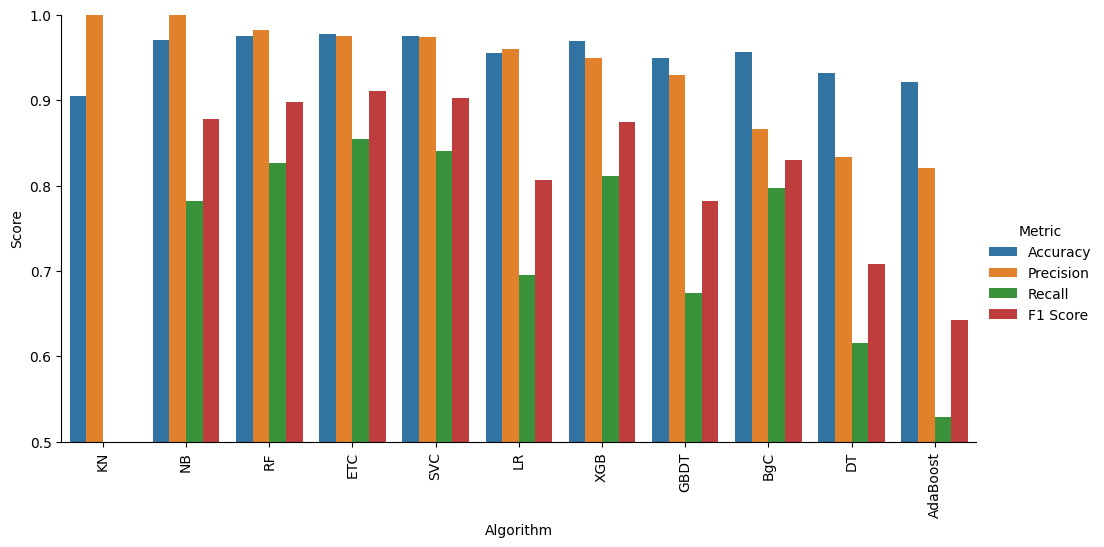

In [76]:
sns.catplot(
    data=performance_df1,
    x='Algorithm',
    y='Score',
    hue='Metric',
    kind='bar',
    height=5,
    aspect=2
)

plt.ylim(0.5, 1.0)
plt.xticks(rotation=90)
plt.show()

## Creating a website

In [77]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))